<a href="https://colab.research.google.com/github/bhavs3260/spotify-popularity-mood-ml/blob/main/spotify_popularity_mood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Tools are ready!")

Tools are ready!


In [2]:
df = pd.read_csv("dataset.csv")
print(df.shape)
df.head()

(35782, 21)


/tmp/ipykernel_1888/2222293708.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,False,0.420,0.1660,...,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933.0,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853.0,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


In [3]:
df.info()
print("Missing values per column:")
print(df.isnull().sum())
print("Repeated songs:", df.duplicated(subset="track_id").sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35782 entries, 0 to 35781
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        35782 non-null  int64  
 1   track_id          35782 non-null  object 
 2   artists           35781 non-null  object 
 3   album_name        35781 non-null  object 
 4   track_name        35781 non-null  object 
 5   popularity        35781 non-null  float64
 6   duration_ms       35781 non-null  float64
 7   explicit          35781 non-null  object 
 8   danceability      35781 non-null  float64
 9   energy            35781 non-null  float64
 10  key               35781 non-null  float64
 11  loudness          35781 non-null  float64
 12  mode              35781 non-null  float64
 13  speechiness       35781 non-null  float64
 14  acousticness      35781 non-null  float64
 15  instrumentalness  35781 non-null  float64
 16  liveness          35781 non-null  float6

In [4]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna()
df = df.drop_duplicates(subset="track_id").reset_index(drop=True)
print("Songs left after cleaning:", df.shape[0])

Songs left after cleaning: 32376


In [5]:
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
                        "valence", "tempo", "duration_ms"]
df[features + ["popularity"]].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
count,32376.000000,32376.000000,32376.000000,32376.000000,32376.000000,32376.000000,32376.000000,32376.000000,32376.000000,3.237600e+04,32376.000000
mean,0.581494,0.634448,-8.529577,0.098428,0.315157,0.199017,0.206109,0.466287,122.401309,2.328982e+05,33.066531
std,0.173325,0.253788,5.165367,0.150768,0.337244,0.337944,0.185749,0.261986,29.094100,1.281691e+05,21.642082
min,0.000000,0.000020,-41.808000,0.000000,0.000000,0.000000,0.011200,0.000000,0.000000,1.745300e+04,0.000000
25%,0.471000,0.463000,-10.393000,0.036100,0.014000,0.000000,0.095800,0.245000,100.261750,1.725000e+05,17.000000
50%,0.596000,0.678000,-7.219500,0.049100,0.163000,0.000162,0.127000,0.450000,122.704500,2.133570e+05,33.000000
75%,0.710000,0.848000,-5.159750,0.085900,0.608000,0.263000,0.258000,0.677000,139.929000,2.666000e+05,50.000000
max,0.983000,1.000000,4.532000,0.965000,0.996000,0.995000,0.995000,0.995000,243.372000,4.789026e+06,100.000000


In [6]:
df["is_hit"] = (df["popularity"] >= 50).astype(int)
print(df["is_hit"].value_counts())
print(df["is_hit"].value_counts(normalize=True))

is_hit
0    24006
1     8370
Name: count, dtype: int64
is_hit
0    0.741475
1    0.258525
Name: proportion, dtype: float64


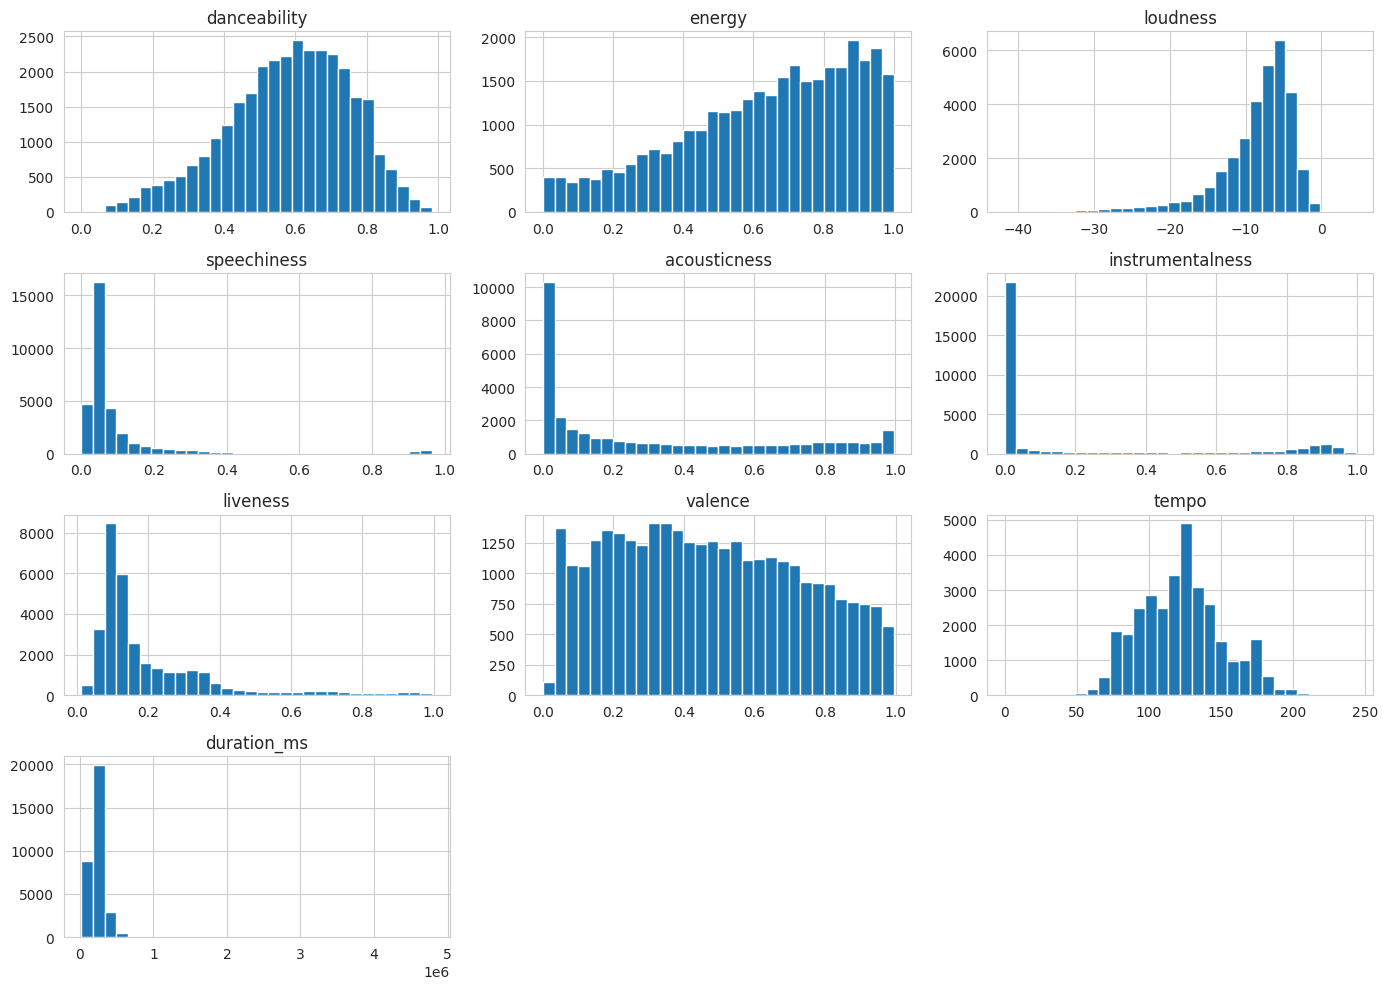

In [7]:
df[features].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

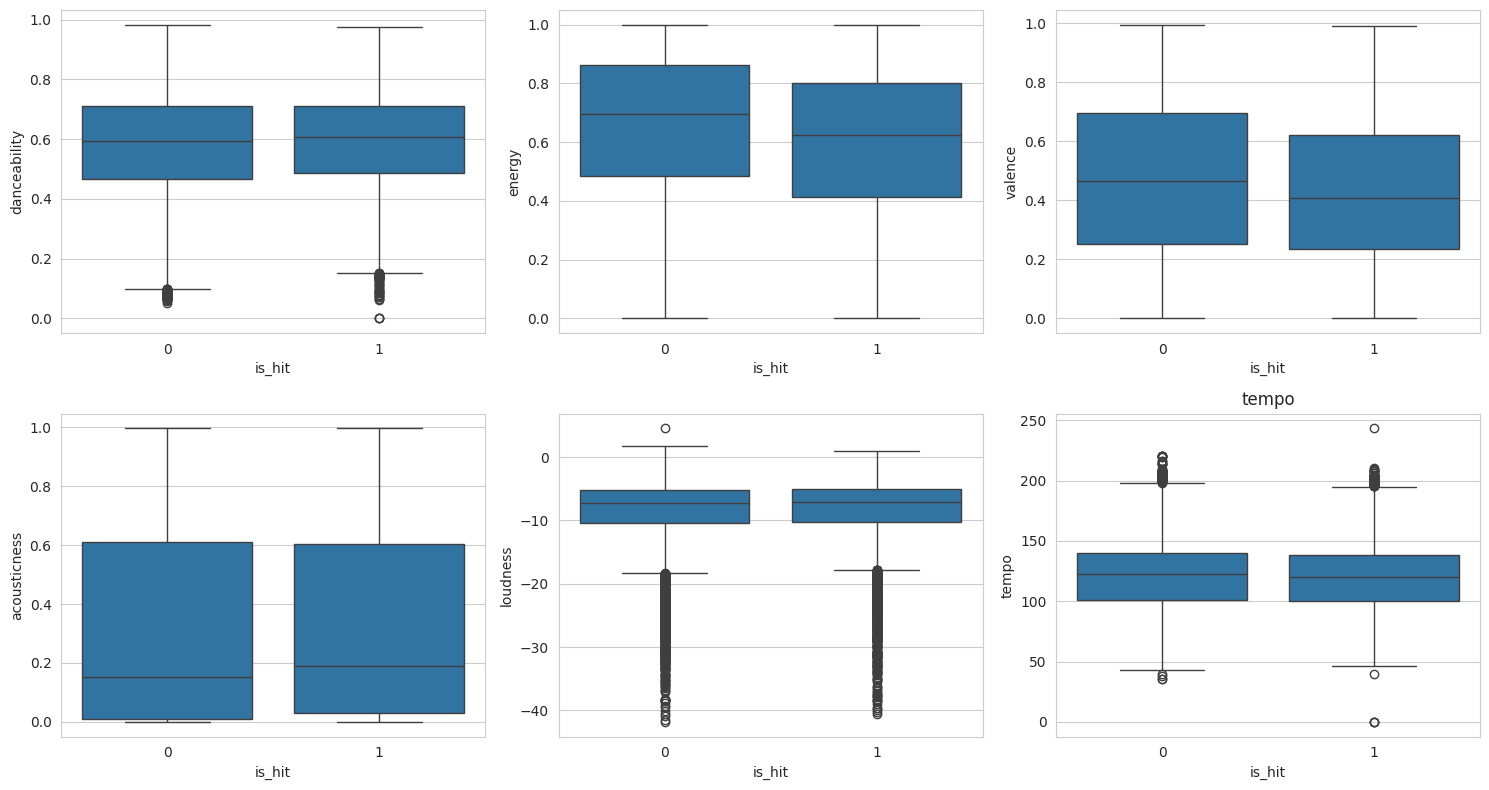

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ["danceability", "energy", "valence", "acousticness", "loudness", "tempo"]):
    sns.boxplot(x="is_hit", y=col, data=df, ax=ax)
ax.set_title(col)
plt.tight_layout()
plt.show()

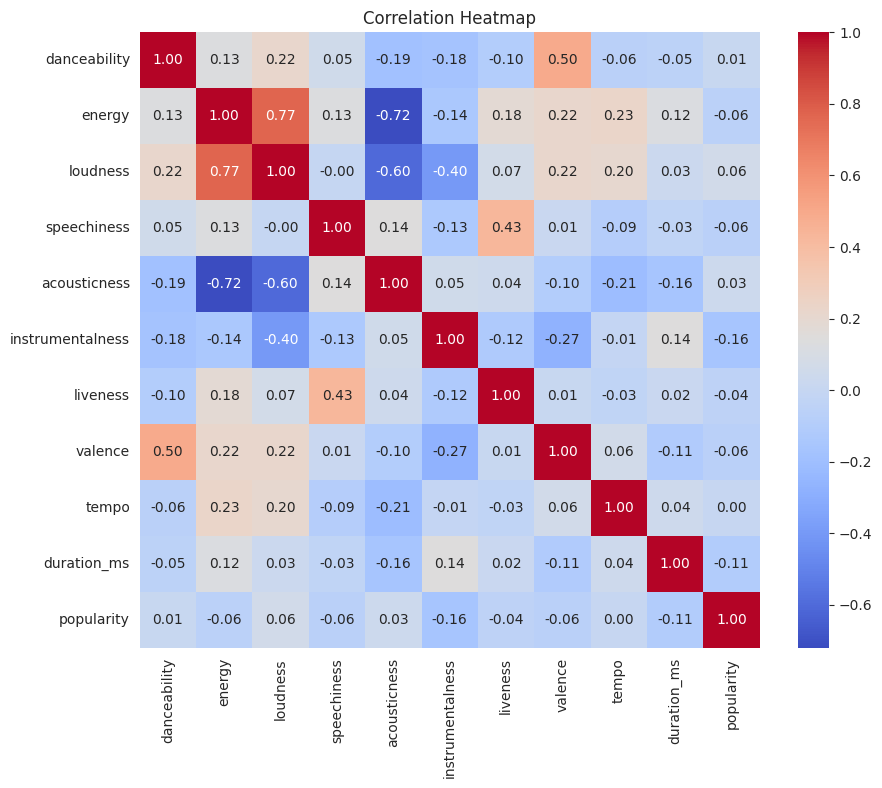

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features + ["popularity"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

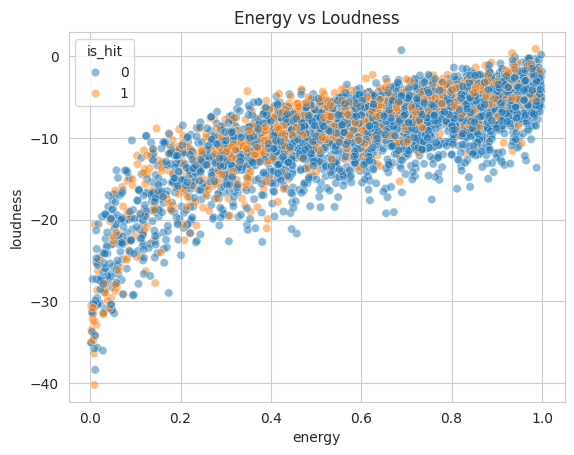

In [10]:
sns.scatterplot(x="energy", y="loudness", hue="is_hit", data=df.sample(5000, random_state=42), alpha=0.5)
plt.title("Energy vs Loudness")
plt.show()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("dataset.csv", on_bad_lines="skip")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna()
df = df.drop_duplicates(subset="track_id").reset_index(drop=True)

features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
                        "valence", "tempo", "duration_ms"]

df["is_hit"] = (df["popularity"] >= 50).astype(int)

print("Songs after cleaning:", df.shape[0])
print(df["is_hit"].value_counts())

Songs after cleaning: 89740
is_hit
0    68531
1    21209
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df["is_hit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training songs:", X_train.shape[0])
print("Test songs:", X_test.shape[0])

Training songs: 71792
Test songs: 17948


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
                "KNN": KNeighborsClassifier(n_neighbors=15),
                    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}
results = []
for name, model in models.items():
                        model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)
prob = model.predict_proba(X_test_scaled)[:, 1]
results.append({
"Model": name,
                                                    "Accuracy": accuracy_score(y_test, pred),
                                                            "Precision": precision_score(y_test, pred),
                                                                    "Recall": recall_score(y_test, pred),
                                                                            "F1": f1_score(y_test, pred),
                                                                                    "ROC-AUC": roc_auc_score(y_test, prob),
                                                                                        })
results_df = pd.DataFrame(results).round(3).sort_values("F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.766,0.788,0.012,0.024,0.681


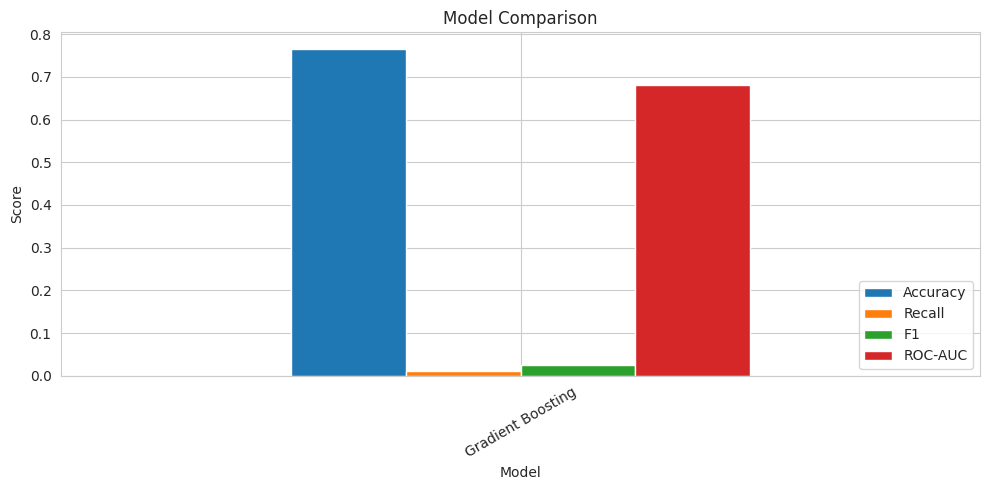

In [18]:
results_df.set_index("Model")[["Accuracy", "Recall", "F1", "ROC-AUC"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()